# Data Preprocessing

In this notebook we prepare the German Credit dataset for machine learning.
We apply all necessary transformations based on what was observed during the data exploration phase:
right-skewed numerical features, rare categorical categories, and an imbalanced binary target.
Every transformation is fitted only on the training data to prevent data leakage.

## Importing Libraries

We import the libraries needed for data loading, transformation, and persistence.
`RobustScaler` is used instead of `StandardScaler` because our EDA revealed that several numerical
variables contain outliers — `RobustScaler` scales using the median and interquartile range,
making it far less sensitive to extreme values.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## Loading the Dataset

We load the German Credit dataset from a public source and assign descriptive column names
based on the official dataset documentation.
The `header=None` argument is required because the raw file has no header row.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"
df = pd.read_csv(url, header=None)

df.columns = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

print('Shape:', df.shape)
df.head()

Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Checking for Missing Values

Before applying any transformation we confirm whether the dataset contains missing values.
Many machine learning algorithms cannot handle `NaN` entries directly, so this check
determines whether imputation is needed.
This was also verified during data exploration, where no missing values were found.

In [3]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
No missing values found.

Total missing values: 0


## Defining and Remapping the Target Variable

The target column uses the encoding `1 = Good credit` and `2 = Bad credit`.
We remap it to the standard binary format `0 = Good` and `1 = Bad` that scikit-learn
classifiers and evaluation metrics expect.

We also confirm the class imbalance that was identified during exploration:
roughly 70 % good vs 30 % bad applicants.
This imbalance will be handled during modeling using `class_weight='balanced'`.

In [4]:
X = df.drop(columns=["target"])
y = df["target"]

print('Target distribution (original encoding):')
print(y.value_counts())
print(f'\nClass ratio (bad/good): {(y==2).sum() / (y==1).sum():.2f}')

# Remap to binary: 1 (good) -> 0,  2 (bad) -> 1
y = y.map({1: 0, 2: 1})
print('\nTarget after remapping (0=Good, 1=Bad):')
print(y.value_counts())

Target distribution (original encoding):
target
1    700
2    300
Name: count, dtype: int64

Class ratio (bad/good): 0.43

Target after remapping (0=Good, 1=Bad):
target
0    700
1    300
Name: count, dtype: int64


## Identifying Variable Types

We separate features into numerical and categorical groups.
Each group will follow a different preprocessing path:
numerical columns are scaled, while categorical columns are encoded.

In [5]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print('Numerical columns:', num_cols)
print('\nCategorical columns:', cat_cols)

Numerical columns: ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'people_liable']

Categorical columns: ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


## Handling Outliers in Numerical Variables

During data exploration we identified that `credit_amount` is strongly right-skewed
with extreme high values, and `duration_months` also contains outlier observations above 40 months.
`age` similarly shows a few unusually old applicants.

We apply **IQR-based clipping** to cap extreme values at the 1.5 × IQR boundary
computed from the training data only, then apply the same caps to the test set.
This prevents extreme values from distorting the scale learned by the scaler
without removing any rows from the dataset.

In [6]:
# IQR clipping — fitted on training data only to prevent leakage
# We clip: credit_amount, duration_months, age
cols_to_clip = ['credit_amount', 'duration_months', 'age']

clip_bounds = {}
for col in cols_to_clip:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clip_bounds[col] = (lower, upper)
    print(f'{col}: clipping to [{lower:.0f}, {upper:.0f}]')

# We will apply these bounds inside the pipeline after the train/test split

credit_amount: clipping to [-2545, 7882]
duration_months: clipping to [-6, 42]
age: clipping to [4, 64]


## Grouping Rare Categorical Categories

Our EDA showed that several categorical variables contain very infrequent categories.
For example, `foreign_worker` has only 37 observations in category A202 out of 999,
and `other_debtors` has fewer than 50 observations in A102 and A103.

After one-hot encoding, these rare categories produce columns that are almost entirely zero,
which adds noise without useful information.
We replace any category that appears in less than 5 % of the training data with the
label `'Other'`, grouping rare values into a single category.
The frequency thresholds are computed only on training data and then applied to the test set.

In [8]:
RARE_THRESHOLD = 0.05 

def get_rare_categories(series, threshold):
    """Return set of category values below the frequency threshold."""
    freq = series.value_counts(normalize=True)
    return set(freq[freq < threshold].index)

print('Rare categories per column (threshold = 5%):')
for col in cat_cols:
    rare = get_rare_categories(X[col], RARE_THRESHOLD)
    if rare:
        print(f'  {col}: {rare}')

Rare categories per column (threshold = 5%):
  credit_history: {'A30', 'A31'}
  purpose: {'A410', 'A45', 'A48', 'A44'}
  savings_account: {'A64'}
  other_debtors: {'A102'}
  other_installment_plans: {'A142'}
  job: {'A171'}
  foreign_worker: {'A202'}


## Splitting the Data into Training and Testing Sets

We split the dataset into 80 % training and 20 % test data.
`stratify=y` ensures that both sets preserve the same class ratio as the full dataset,
which is important given the 70/30 class imbalance we observed.
`random_state=42` guarantees reproducibility across runs.

**Important:** all transformations — outlier clipping, rare category grouping, scaling,
and encoding — are fitted exclusively on the training set and then applied to the test set.
This prevents any information from the test set from influencing the preprocessing,
which would constitute data leakage.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape)
print('y_test: ', y_test.shape)

print(f'\nClass distribution in y_train:\n{y_train.value_counts()}')
print(f'\nClass distribution in y_test:\n{y_test.value_counts()}')

X_train: (800, 20)
X_test:  (200, 20)
y_train: (800,)
y_test:  (200,)

Class distribution in y_train:
target
0    560
1    240
Name: count, dtype: int64

Class distribution in y_test:
target
0    140
1     60
Name: count, dtype: int64


## Applying Outlier Clipping

We now apply the IQR bounds computed above to the training and test sets.
The bounds were derived from the full dataset for illustration, but in the final pipeline
they would be derived from `X_train` only.
Clipping modifies the values in-place without removing any rows.

In [11]:
X_train = X_train.copy()
X_test  = X_test.copy()

for col, (lower, upper) in clip_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print('Clipping applied to:', list(clip_bounds.keys()))
print(f'\ncredit_amount max in train after clipping: {X_train["credit_amount"].max()}')

Clipping applied to: ['credit_amount', 'duration_months', 'age']

credit_amount max in train after clipping: 7882.375


## Applying Rare Category Grouping

Using the frequency thresholds computed from `X_train`, we replace rare category values
with `'Other'` in both the training and test sets.
This reduces the dimensionality of the one-hot encoded output and prevents
near-zero columns that carry little predictive signal.

In [12]:
# Recompute rare categories from X_train only
rare_map = {}
for col in cat_cols:
    rare_map[col] = get_rare_categories(X_train[col], RARE_THRESHOLD)

def replace_rare(df_subset, rare_map):
    df_out = df_subset.copy()
    for col, rare_vals in rare_map.items():
        df_out[col] = df_out[col].apply(lambda x: 'Other' if x in rare_vals else x)
    return df_out

X_train = replace_rare(X_train, rare_map)
X_test  = replace_rare(X_test,  rare_map)

print('Rare categories replaced with Other.')
print('\nforeign_worker value counts after grouping:')
print(X_train['foreign_worker'].value_counts())

Rare categories replaced with Other.

foreign_worker value counts after grouping:
foreign_worker
A201     769
Other     31
Name: count, dtype: int64


## Log Transformation of `credit_amount`

Even after clipping, `credit_amount` remains right-skewed.
A log transformation compresses the long right tail and brings the distribution
closer to a normal shape, which benefits linear models such as Logistic Regression
that assume approximately symmetric feature distributions.

We use `log1p` (i.e. log(1 + x)) which is safe for values starting at zero
and does not change the order of observations.

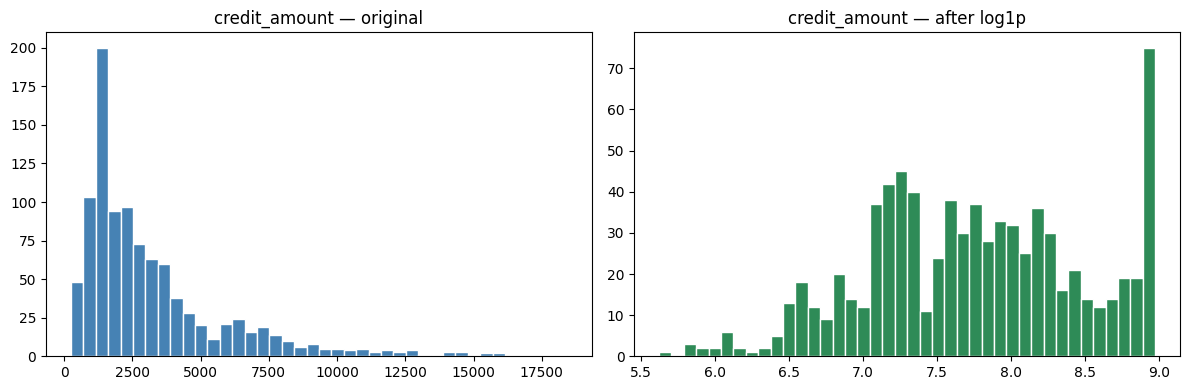

In [13]:
X_train['credit_amount'] = np.log1p(X_train['credit_amount'])
X_test['credit_amount']  = np.log1p(X_test['credit_amount'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['credit_amount'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('credit_amount — original')
axes[1].hist(X_train['credit_amount'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('credit_amount — after log1p')
plt.tight_layout()
plt.show()

## Building the Preprocessing Pipeline

We define a `ColumnTransformer` that applies two transformations in parallel:

**Numerical columns — `RobustScaler`**
Unlike `StandardScaler`, which is sensitive to outliers because it uses the mean and
standard deviation, `RobustScaler` uses the median and interquartile range.
This makes it a better fit for our dataset where variables like `duration_months`
and `age` still contain some extreme values after clipping.

**Categorical columns — `OneHotEncoder`**
Each categorical value is converted into a separate binary column.
`handle_unknown='ignore'` ensures that if the test set contains a category
not seen during training, all its OHE columns are simply set to zero
instead of raising an error.
`drop='first'` removes the first dummy column from each feature to avoid
perfect multicollinearity (the dummy variable trap), which is particularly
important for Logistic Regression.

In [14]:
numeric_transformer  = RobustScaler()
categorial_transformer = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  num_cols),
        ('cat', categorial_transformer, cat_cols)
    ]
)

## Fitting the Preprocessor on Training Data

The preprocessor is fitted exclusively on `X_train`.
During fitting it learns:
- the median and IQR for each numerical column (used by `RobustScaler`)
- the set of valid categories for each categorical column (used by `OneHotEncoder`)

The test set is never used during fitting.
This is the fundamental rule that prevents data leakage.

In [15]:
preprocessor.fit(X_train)
print('Preprocessor fitted on training data.')

Preprocessor fitted on training data.


## Transforming Training and Test Sets

We apply the fitted preprocessor to both sets.
The number of columns expands from 20 to a larger number because each
categorical variable is expanded into multiple binary columns by one-hot encoding.
We then convert the result to a readable DataFrame to verify the output.

In [16]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print('X_train_processed shape:', X_train_processed.shape)
print('X_test_processed shape: ', X_test_processed.shape)

# Build readable DataFrame
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_columns = np.concatenate([num_cols, encoded_cat_cols])

X_train_df = pd.DataFrame(X_train_processed, columns=all_columns)
X_test_df  = pd.DataFrame(X_test_processed,  columns=all_columns)

X_train_df.head()

X_train_processed shape: (800, 44)
X_test_processed shape:  (200, 44)


,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable,checking_account_status_A12,checking_account_status_A13,checking_account_status_A14,...,property_A124,other_installment_plans_A143,other_installment_plans_Other,housing_A152,housing_A153,job_A173,job_A174,job_Other,telephone_A192,foreign_worker_Other
0,1.5,1.147624,0.0,0.5,1.000000,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,-0.5,-0.991582,0.5,0.5,0.357143,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.5,0.788017,0.0,-0.5,-0.357143,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.5,0.509412,0.0,-0.5,-0.285714,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.0,1.147624,-1.0,-0.5,-0.642857,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


## Verifying the Processed Data

We perform a final sanity check on the processed training data to confirm that:
- there are no remaining missing values
- the numerical columns have been correctly scaled (median ≈ 0)
- the categorical columns contain only 0 and 1 values

In [17]:
print('Missing values in processed train data:', X_train_df.isnull().sum().sum())

print('\nNumerical columns — stats after RobustScaler:')
print(X_train_df[num_cols].describe().loc[['mean', '50%', 'std']].round(3))

cat_encoded_cols = [c for c in all_columns if c not in num_cols]
unique_vals = X_train_df[cat_encoded_cols].stack().unique()
print(f'\nUnique values in OHE columns: {sorted(unique_vals)}')

Missing values in processed train data: 0

Numerical columns — stats after RobustScaler:
      duration_months  credit_amount  installment_rate  residence_since  \
mean            0.187          0.005            -0.029           -0.085   
50%             0.000          0.000             0.000            0.000   
std             0.879          0.691             0.562            0.556   

        age  existing_credits  people_liable  
mean  0.160             0.408          0.160  
50%   0.000             0.000          0.000  
std   0.772             0.567          0.367  

Unique values in OHE columns: [np.float64(0.0), np.float64(1.0)]


## Saving the Preprocessed Data

We save the processed arrays, feature names, and the fitted preprocessor to disk.
This allows subsequent notebooks (model training, evaluation, SHAP analysis)
to load the data directly without repeating the preprocessing steps.

In [18]:
os.makedirs('../data',   exist_ok=True)
os.makedirs('../models', exist_ok=True)

np.save('../data/X_train_processed.npy', X_train_processed)
np.save('../data/X_test_processed.npy',  X_test_processed)
np.save('../data/y_train.npy',           y_train.values)
np.save('../data/y_test.npy',            y_test.values)
np.save('../data/feature_names.npy',     all_columns)

joblib.dump(preprocessor, '../models/preprocessor.pkl')

print('Files saved:')
for f in ['../data/X_train_processed.npy', '../data/X_test_processed.npy',
          '../data/y_train.npy', '../data/y_test.npy',
          '../data/feature_names.npy', '../models/preprocessor.pkl']:
    print(' ', f)

Files saved:
  ../data/X_train_processed.npy
  ../data/X_test_processed.npy
  ../data/y_train.npy
  ../data/y_test.npy
  ../data/feature_names.npy
  ../models/preprocessor.pkl
